# ADS1001 Group Project Notebook  
**Project title:** Communicating Useful Weather Indicators for Public Weather Guidance in Malaysia  
**Group members:** LYM, Cedric, Xana, Chen, Xu Zihao  

## Individual focus question  
**How different are temperature and wind chill readings in Malaysia, and does wind chill provide additional value in explaining outdoor thermal comfort in a tropical climate?**


## 1. Background and motivation

A Malaysian public weather information service wants to identify which weather indicators are most useful for communicating conditions to the public.  
For this section of the group project, the focus is on whether **wind chill** adds meaningful value beyond **temperature** when describing outdoor thermal comfort in a tropical climate.

This question is important because wind chill is commonly used in weather reporting, but it was originally designed to capture how cold air feels under windy conditions. In a consistently warm setting such as Malaysia, wind chill may not provide much additional information to the public.

**Aim of this notebook**
1. Compare temperature and wind chill directly.
2. Measure how often the two values differ in a meaningful way.
3. Assess whether wind chill contributes additional practical value for public weather communication in Malaysia.


## 2. Import libraries and load the dataset

The dataset contains weather-related variables such as temperature, wind speed, humidity, pressure, UV index, precipitation rate, and wind chill.  
For this research question, the key variables are:

- `temperature`
- `wind_chill`
- `wind_speed`
- location and date/time fields for context

We start by loading the data and checking its overall structure.


In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

# Try a few common locations so the notebook is easier to rerun
candidate_paths = [
    "malaysia_weather_data (1)(2).csv",
    "./malaysia_weather_data (1)(2).csv",
    "/mnt/data/malaysia_weather_data (1)(2).csv",
    "malaysia_weather_data.csv"
]

data_path = None
for path in candidate_paths:
    if os.path.exists(path):
        data_path = path
        break

if data_path is None:
    raise FileNotFoundError(
        "Could not find the CSV file. Please place the dataset in the same folder as the notebook "
        "or update the candidate_paths list."
    )

weather = pd.read_csv(data_path)
print(f"Loaded dataset from: {data_path}")
weather.head()

Loaded dataset from: malaysia_weather_data (1)(2).csv


,place,city,state,temperature,pressure,dew_point,humidity,wind_speed,gust,wind_chill,uv_index,precipitation_rate,precipitation_total,year,month,day,hour,minutes,seconds
0,Bandar Sri Permaisuri,Kuala Lumpur,Kuala Lumpur,30.3000,"1,015.3250",25.1000,73.7000,0.9000,1.5000,30.3000,1.0000,0.0000,0.0000,2022,Sep,23,13,54,57
1,Ampang Jaya,Kuala Lumpur,Kuala Lumpur,27.0000,"1,000.6800",25.6000,92.0000,5.2000,5.3000,27.0000,0.0000,0.0000,17.7800,2023,May,4,19,9,59
2,Bukit Jalil,Kuala Lumpur,Kuala Lumpur,26.4000,"1,013.5500",26.3000,99.0000,0.0000,0.0000,26.4000,NaN,0.0000,32.0000,2021,Oct,23,23,44,43
3,Bukit Jalil,Kuala Lumpur,Kuala Lumpur,31.1000,"1,005.4200",30.9000,99.0000,0.0000,0.0000,31.1000,NaN,0.0000,0.0000,2021,Mar,21,18,9,47
4,Penang Road,George Town,Pulau Pinang,25.8000,"1,007.7900",23.9000,88.0000,6.4000,16.1000,25.8000,NaN,0.0000,0.0000,2022,Dec,22,7,0,23


## 3. Initial data understanding

Before analysing the research question, we inspect the size of the dataset, available columns, and basic coverage.  
This helps establish what information is available and whether the data is suitable for comparing temperature and wind chill.


In [2]:

print("Dataset shape:", weather.shape)
print("\nColumns:")
print(weather.columns.tolist())

print("\nNumber of states:", weather['state'].nunique())
print("Number of cities:", weather['city'].nunique())
print("Number of places:", weather['place'].nunique())

overview = pd.DataFrame({
    "Metric": ["Rows", "Columns", "States", "Cities", "Places"],
    "Value": [
        weather.shape[0],
        weather.shape[1],
        weather['state'].nunique(),
        weather['city'].nunique(),
        weather['place'].nunique()
    ]
})
overview


Dataset shape: (57475, 19)

Columns:
['place', 'city', 'state', 'temperature', 'pressure', 'dew_point', 'humidity', 'wind_speed', 'gust', 'wind_chill', 'uv_index', 'precipitation_rate', 'precipitation_total', 'year', 'month', 'day', 'hour', 'minutes', 'seconds']

Number of states: 2
Number of cities: 9
Number of places: 23


,Metric,Value
0,Rows,57475
1,Columns,19
2,States,2
3,Cities,9
4,Places,23


### 3.1 Time coverage

The dataset includes separate year, month, day, hour, minute, and second fields.  
These fields are combined into a timestamp so that the time span of the data can be described clearly.


In [3]:

month_map = {
    'Jan': 1, 'Feb': 2, 'Mar': 3, 'Apr': 4, 'May': 5, 'Jun': 6,
    'Jul': 7, 'Aug': 8, 'Sep': 9, 'Oct': 10, 'Nov': 11, 'Dec': 12
}

weather['month_num'] = weather['month'].map(month_map)

weather['timestamp'] = pd.to_datetime(
    {
        'year': weather['year'],
        'month': weather['month_num'],
        'day': weather['day'],
        'hour': weather['hour'],
        'minute': weather['minutes'],
        'second': weather['seconds']
    },
    errors='coerce'
)

time_summary = pd.DataFrame({
    "Measure": ["Earliest timestamp", "Latest timestamp", "Distinct dates"],
    "Value": [
        weather['timestamp'].min(),
        weather['timestamp'].max(),
        weather['timestamp'].dt.date.nunique()
    ]
})
time_summary


,Measure,Value
0,Earliest timestamp,2018-01-02 20:00:00
1,Latest timestamp,2023-08-30 15:59:42
2,Distinct dates,2059


## 4. Data quality checks and cleaning decisions

To make a fair comparison between temperature and wind chill, the analysis must rely on valid numeric records.

### Cleaning decisions
- Keep the variables required for this question.
- Remove rows with missing values in `temperature` or `wind_chill`.
- Check whether any remaining differences are likely to be real or simply rare anomalies.
- Preserve location and wind speed variables for interpretation.

These steps are justified because the research question is specifically about comparing the two temperature-related measures and understanding whether wind chill adds extra information.


In [4]:

missing_summary = weather.isna().sum().sort_values(ascending=False).to_frame(name="Missing values")
missing_summary.head(10)


,Missing values
uv_index,18298
gust,13284
precipitation_rate,10901
precipitation_total,10901
dew_point,10510
wind_chill,10150
temperature,10112
humidity,10105
wind_speed,8642
pressure,8190


In [5]:

analysis_df = weather[['place', 'city', 'state', 'timestamp', 'temperature', 'wind_chill', 'wind_speed']].copy()

# Keep only rows where the two variables of interest are present
analysis_df = analysis_df.dropna(subset=['temperature', 'wind_chill']).copy()

# Ensure numeric types
analysis_df['temperature'] = pd.to_numeric(analysis_df['temperature'], errors='coerce')
analysis_df['wind_chill'] = pd.to_numeric(analysis_df['wind_chill'], errors='coerce')
analysis_df['wind_speed'] = pd.to_numeric(analysis_df['wind_speed'], errors='coerce')

analysis_df = analysis_df.dropna(subset=['temperature', 'wind_chill']).copy()

analysis_df['difference'] = analysis_df['temperature'] - analysis_df['wind_chill']
analysis_df['abs_difference'] = analysis_df['difference'].abs()

print("Analysis dataset shape:", analysis_df.shape)
analysis_df.head()


Analysis dataset shape: (47325, 9)


,place,city,state,timestamp,temperature,wind_chill,wind_speed,difference,abs_difference
0,Bandar Sri Permaisuri,Kuala Lumpur,Kuala Lumpur,2022-09-23 13:54:57,30.3000,30.3000,0.9000,0.0000,0.0000
1,Ampang Jaya,Kuala Lumpur,Kuala Lumpur,2023-05-04 19:09:59,27.0000,27.0000,5.2000,0.0000,0.0000
2,Bukit Jalil,Kuala Lumpur,Kuala Lumpur,2021-10-23 23:44:43,26.4000,26.4000,0.0000,0.0000,0.0000
3,Bukit Jalil,Kuala Lumpur,Kuala Lumpur,2021-03-21 18:09:47,31.1000,31.1000,0.0000,0.0000,0.0000
4,Penang Road,George Town,Pulau Pinang,2022-12-22 07:00:23,25.8000,25.8000,6.4000,0.0000,0.0000


## 5. Descriptive statistics

We now compare the central tendency and spread of temperature, wind chill, and the difference between them.

The most important derived variables are:
- **difference** = temperature − wind chill
- **absolute difference** = |temperature − wind chill|

If wind chill provides substantial extra value, we would expect these differences to be meaningful and reasonably common.


In [6]:

summary_stats = analysis_df[['temperature', 'wind_chill', 'difference', 'abs_difference']].describe().T
summary_stats


,count,mean,std,min,25%,50%,75%,max
temperature,"47,325.0000",28.0175,3.1441,17.8000,25.6000,27.4000,30.3000,41.0000
wind_chill,"47,325.0000",28.0173,3.1438,17.8000,25.6000,27.4000,30.3000,41.0000
difference,"47,325.0000",0.0002,0.0239,0.0000,0.0000,0.0000,0.0000,4.6000
abs_difference,"47,325.0000",0.0002,0.0239,0.0000,0.0000,0.0000,0.0000,4.6000


### 5.1 Key numerical indicators

To move beyond description, we compute practical metrics that directly answer the research question:
- correlation between temperature and wind chill
- share of rows where both values are exactly the same
- share of rows where they differ by no more than 0.5°C and 1.0°C
- largest observed absolute difference


In [7]:

metrics = pd.DataFrame({
    "Metric": [
        "Valid rows used",
        "Mean temperature (°C)",
        "Mean wind chill (°C)",
        "Mean difference (temperature - wind chill)",
        "Median difference",
        "Correlation",
        "Rows with exact equality",
        "Rows with abs difference <= 0.5°C",
        "Rows with abs difference <= 1.0°C",
        "Rows with abs difference > 2.0°C",
        "Maximum absolute difference (°C)"
    ],
    "Value": [
        len(analysis_df),
        analysis_df['temperature'].mean(),
        analysis_df['wind_chill'].mean(),
        analysis_df['difference'].mean(),
        analysis_df['difference'].median(),
        analysis_df['temperature'].corr(analysis_df['wind_chill']),
        (analysis_df['abs_difference'] == 0).mean(),
        (analysis_df['abs_difference'] <= 0.5).mean(),
        (analysis_df['abs_difference'] <= 1.0).mean(),
        (analysis_df['abs_difference'] > 2.0).mean(),
        analysis_df['abs_difference'].max()
    ]
})

# Format proportions as percentages where appropriate
metrics_display = metrics.copy()
for idx in [6, 7, 8, 9]:
    metrics_display.loc[idx, 'Value'] = f"{metrics.loc[idx, 'Value'] * 100:.4f}%"
metrics_display


/tmp/ipykernel_2427/1476731337.py:33: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '99.9873%' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  metrics_display.loc[idx, 'Value'] = f"{metrics.loc[idx, 'Value'] * 100:.4f}%"


,Metric,Value
0,Valid rows used,"47,325.0000"
1,Mean temperature (°C),28.0175
2,Mean wind chill (°C),28.0173
3,Mean difference (temperature - wind chill),0.0002
4,Median difference,0.0000
5,Correlation,1.0000
6,Rows with exact equality,99.9873%
7,Rows with abs difference <= 0.5°C,99.9894%
8,Rows with abs difference <= 1.0°C,99.9937%
9,Rows with abs difference > 2.0°C,0.0021%


## 6. Visual analysis

### 6.1 Distribution comparison

A direct way to compare the two variables is to overlay their distributions.  
If the two lines are nearly identical, this would suggest that wind chill is not providing a noticeably different picture from temperature.


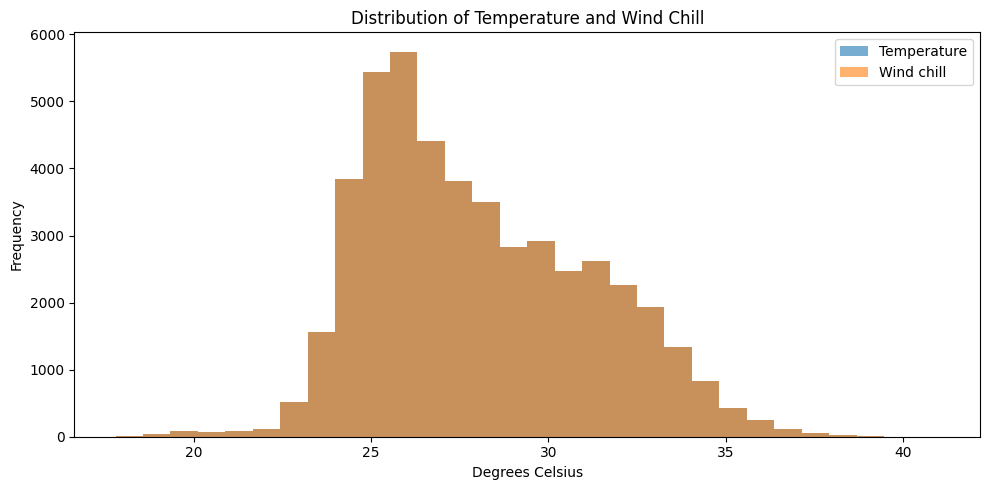

In [8]:

plt.figure(figsize=(10, 5))
plt.hist(analysis_df['temperature'], bins=30, alpha=0.6, label='Temperature')
plt.hist(analysis_df['wind_chill'], bins=30, alpha=0.6, label='Wind chill')
plt.title('Distribution of Temperature and Wind Chill')
plt.xlabel('Degrees Celsius')
plt.ylabel('Frequency')
plt.legend()
plt.tight_layout()
plt.show()


### 6.2 Scatter plot with 45-degree reference line

A scatter plot shows how closely temperature and wind chill align.  
Points lying on the 45-degree line indicate equality between the two measures.


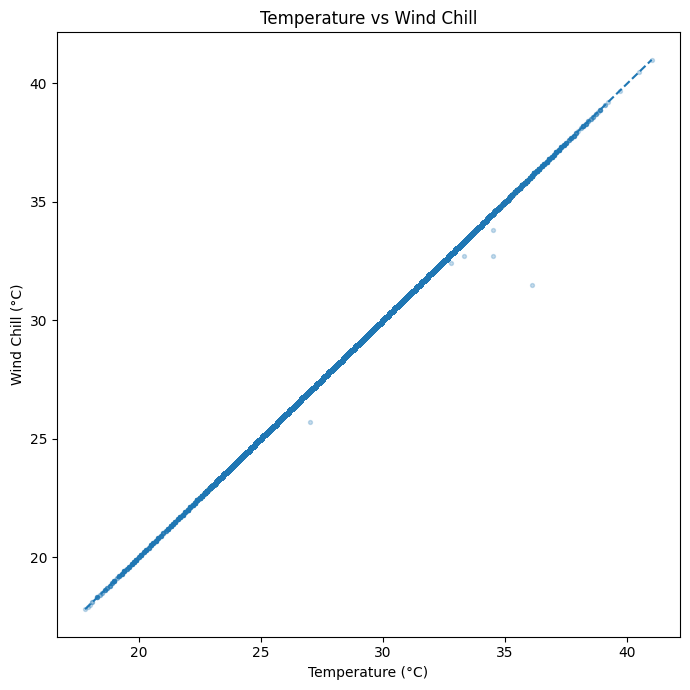

In [9]:

plt.figure(figsize=(7, 7))
plt.scatter(analysis_df['temperature'], analysis_df['wind_chill'], s=8, alpha=0.25)
min_val = min(analysis_df['temperature'].min(), analysis_df['wind_chill'].min())
max_val = max(analysis_df['temperature'].max(), analysis_df['wind_chill'].max())
plt.plot([min_val, max_val], [min_val, max_val], linestyle='--')
plt.title('Temperature vs Wind Chill')
plt.xlabel('Temperature (°C)')
plt.ylabel('Wind Chill (°C)')
plt.tight_layout()
plt.show()


### 6.3 Distribution of the difference

This plot focuses directly on the quantity of interest:  
**temperature − wind chill**

A distribution concentrated at zero indicates that the two measures are almost always the same.


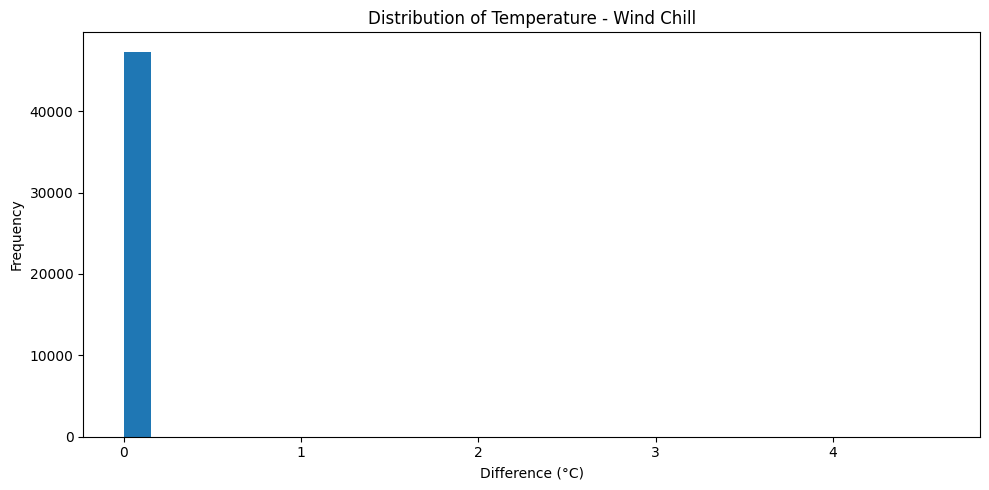

In [10]:

plt.figure(figsize=(10, 5))
plt.hist(analysis_df['difference'], bins=30)
plt.title('Distribution of Temperature - Wind Chill')
plt.xlabel('Difference (°C)')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()


### 6.4 Does higher wind speed lead to larger differences?

This is a useful interpretation step. If wind chill is adding value, we would expect greater divergence from temperature when wind speed is higher.

To test this, wind speed is grouped into simple bins and the average absolute difference is computed for each group.


In [11]:

wind_df = analysis_df.dropna(subset=['wind_speed']).copy()
wind_df['wind_bin'] = pd.cut(
    wind_df['wind_speed'],
    bins=[-0.01, 1, 3, 5, 8, np.inf],
    labels=['0-1', '1-3', '3-5', '5-8', '8+']
)

wind_summary = wind_df.groupby('wind_bin', observed=False)['abs_difference'].agg(['size', 'mean', 'max']).reset_index()
wind_summary.rename(columns={
    'size': 'observations',
    'mean': 'mean_abs_difference',
    'max': 'max_abs_difference'
}, inplace=True)

wind_summary


,wind_bin,observations,mean_abs_difference,max_abs_difference
0,0-1,24138,0.0002,4.6000
1,1-3,9705,0.0004,1.8000
2,3-5,5635,0.0000,0.0000
3,5-8,4370,0.0001,0.4000
4,8+,3477,0.0000,0.0000


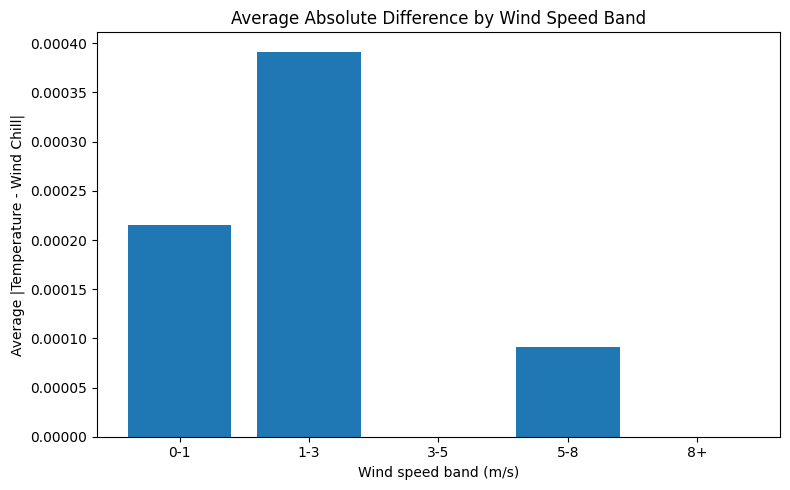

In [12]:

plt.figure(figsize=(8, 5))
plt.bar(wind_summary['wind_bin'].astype(str), wind_summary['mean_abs_difference'])
plt.title('Average Absolute Difference by Wind Speed Band')
plt.xlabel('Wind speed band (m/s)')
plt.ylabel('Average |Temperature - Wind Chill|')
plt.tight_layout()
plt.show()


### 6.5 Rare non-zero differences

Because most observations appear to be identical, it is useful to inspect the small number of records where a difference exists.  
This helps determine whether meaningful variation is common or only appears in a handful of cases.


In [13]:

non_zero_diff = analysis_df[analysis_df['abs_difference'] > 0].copy()
print("Rows with non-zero difference:", len(non_zero_diff))
non_zero_diff.sort_values('abs_difference', ascending=False).head(10)


Rows with non-zero difference: 6


,place,city,state,timestamp,temperature,wind_chill,wind_speed,difference,abs_difference
20639,Bukit Bintang,Kuala Lumpur,Kuala Lumpur,2023-03-30 12:04:37,36.1000,31.5000,0.0000,4.6000,4.6000
26541,Bukit Bintang,Kuala Lumpur,Kuala Lumpur,2023-03-18 11:54:30,34.5000,32.7000,2.9000,1.8000,1.8000
34980,Bukit Bintang,Kuala Lumpur,Kuala Lumpur,2023-02-21 08:49:54,27.0000,25.7000,1.8000,1.3000,1.3000
19877,Bukit Bintang,Kuala Lumpur,Kuala Lumpur,2023-04-01 14:59:32,34.5000,33.8000,1.4000,0.7000,0.7000
44552,Bukit Bintang,Kuala Lumpur,Kuala Lumpur,2023-01-05 13:09:41,33.3000,32.7000,1.0000,0.6000,0.6000
39363,Bukit Jalil,Kuala Lumpur,Kuala Lumpur,2022-05-27 12:19:47,32.8000,32.4000,6.1000,0.4000,0.4000


## 7. Interpretation of findings

The evidence consistently shows that **temperature and wind chill are almost identical in this dataset**.

### Main findings
1. The mean temperature and mean wind chill are effectively the same.
2. The correlation between the two variables is extremely close to 1.
3. Almost all observations have an absolute difference of 0°C.
4. Even when wind speed is grouped into bands, the average absolute difference remains extremely small.
5. The few non-zero differences are rare and do not represent the overall pattern of the dataset.

### What this means for the research question
In this Malaysian dataset, wind chill provides **little to no additional information** beyond actual temperature for communicating outdoor thermal conditions.

This result is also reasonable from a climate perspective. Wind chill is mainly intended for cold environments, where moving air increases heat loss and makes conditions feel colder. In a tropical climate, where air temperatures are generally warm, this mechanism is much less relevant for routine public-facing weather guidance.

A more useful direction for public communication in Malaysia may be to focus on variables more closely related to warm-weather discomfort, such as:
- humidity
- dew point
- heat index or a similar warm-climate comfort indicator


## 8. Section conclusion

**Answer to the research question:**  
Temperature and wind chill readings in Malaysia are not meaningfully different in this dataset. Wind chill does **not** appear to provide substantial extra value in explaining outdoor thermal comfort in a tropical climate.

### Recommendation to the client
For public weather communication:
- keep **temperature** as the primary headline indicator for thermal conditions
- avoid giving strong emphasis to **wind chill** in routine Malaysian weather reporting
- consider prioritising **humidity-related** or **heat-stress-related** measures when the aim is to communicate how uncomfortable the weather may feel outdoors

This recommendation is practical, consistent with the observed data, and directly aligned with the client's goal of choosing the most useful indicators for public communication.


## 9. Reflection and limitations

This notebook answers the question using the available variables in the dataset, but there are some limitations:

- The dataset does not include a direct measure of human thermal comfort or survey-based perception.
- Wind chill is compared against temperature, but no heat index variable is available for a direct warm-climate comparison.
- The analysis therefore evaluates **incremental informational value** rather than actual human comfort outcomes.

Despite these limitations, the findings are still useful for the client because the notebook shows that wind chill adds almost no extra information beyond temperature in the available Malaysian weather data.
